# XOR, Linear Separability, and Why Non-linearity Matters

This notebook connects a few ideas that show up early in deep learning:

- **XOR** as the smallest example of a *feature interaction*
- What **linearly separable** means in practice
- How **perceptron**, **linear regression**, and **logistic regression** are related
- Why **activation functions** (non-linearity) are the key ingredient behind deep learning

We use minimal math and rely on plots + code.

**Prerequisites:** [01_intro_neural_networks.ipynb](../01_intro_neural_networks.ipynb), [02_pytorch_basics.ipynb](../02_pytorch_basics.ipynb)

## The XOR idea

XOR means: **either** condition A **or** condition B is true, **but not both**.

| x₁ | x₂ | XOR |
|----|----|-----|
| 0  | 0  | 0   |
| 0  | 1  | 1   |
| 1  | 0  | 1   |
| 1  | 1  | 0   |

Why do we care? Because XOR is the smallest example that requires **combining conditions** — the kind of logic that appears in real projects as feature interactions.

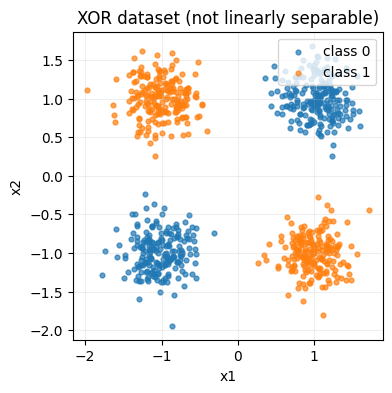

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def make_noisy_xor(n_per_corner: int = 200, noise: float = 0.25, seed: int = 0):
    rng = np.random.default_rng(seed)
    corners = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]], dtype=np.float32)
    X = np.repeat(corners, repeats=n_per_corner, axis=0)
    X = X + rng.normal(0.0, noise, size=X.shape).astype(np.float32)
    y = ((X[:, 0] > 0) ^ (X[:, 1] > 0)).astype(np.float32)
    return X, y

X, y = make_noisy_xor()

plt.figure(figsize=(4, 4))
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=12, alpha=0.7, label="class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=12, alpha=0.7, label="class 1")
plt.title("XOR dataset (not linearly separable)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.2)
plt.legend(loc="upper right")
plt.show()

## What does "linearly separable" mean?

A model is **linear** (for classification) if it can only separate classes using **one straight boundary**:

- A **line** in 2D
- A **plane** in 3D
- A **hyperplane** in higher dimensions

If the data can't be split by one straight boundary, then **no amount of training** will make a purely linear model solve it — it's a *representation* limitation, not an optimization limitation.

## Perceptron, linear regression, logistic regression

All three start with the same core computation — a **linear score**:

$$\text{score} = w_1 x_1 + w_2 x_2 + \ldots + b$$

They differ in what happens *after* and what loss they optimize:

| Model | After the linear score | Loss | Use for |
|-------|----------------------|------|---------|
| **Linear regression** | Nothing (raw number) | MSE | Regression |
| **Perceptron (classic)** | Hard threshold (step function) | Perceptron loss | Binary classification (historical) |
| **Logistic regression** | Smooth threshold (sigmoid) | BCE | Binary classification (modern baseline) |

In PyTorch, a single `nn.Linear(2, 1)` + sigmoid + BCE loss **is** logistic regression.

## Demo: linear models fail on XOR

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(0)

X_t = torch.from_numpy(X)
y_t = torch.from_numpy(y).reshape(-1, 1)

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = (torch.sigmoid(logits) > 0.5).to(dtype=y_true.dtype)
    return float((preds == y_true).to(torch.float32).mean().item())

def plot_probability_surface(ax, model: nn.Module, title: str):
    xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 250), np.linspace(-2.5, 2.5, 250))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()].astype(np.float32))
    with torch.no_grad():
        probs = torch.sigmoid(model(grid)).reshape(xx.shape).cpu().numpy()
    ax.contourf(xx, yy, probs, levels=25, alpha=0.65)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, alpha=0.2)

def scatter_data(ax):
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=10, alpha=0.7, label="class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=10, alpha=0.7, label="class 1")
    ax.legend(loc="upper right")

Linear regression accuracy: 0.500
Logistic regression accuracy: 0.500


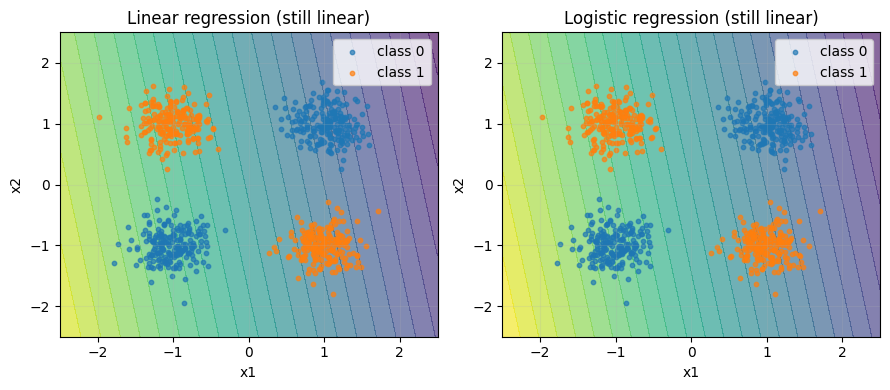

In [ ]:
# 1) Linear regression forced into classification (MSE + threshold)
linreg = nn.Linear(2, 1)
opt = torch.optim.SGD(linreg.parameters(), lr=0.1)
for _ in range(400):
    opt.zero_grad()
    loss = nn.MSELoss()(linreg(X_t), y_t)
    loss.backward()
    opt.step()

# 2) Logistic regression (BCEWithLogitsLoss)
logreg = nn.Linear(2, 1)
opt = torch.optim.SGD(logreg.parameters(), lr=0.5)
for _ in range(400):
    opt.zero_grad()
    loss = nn.BCEWithLogitsLoss()(logreg(X_t), y_t)
    loss.backward()
    opt.step()

with torch.no_grad():
    print(f"Linear regression accuracy: {accuracy_from_logits(linreg(X_t), y_t):.3f}")
    print(f"Logistic regression accuracy: {accuracy_from_logits(logreg(X_t), y_t):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_probability_surface(axes[0], linreg, "Linear regression (still linear)")
scatter_data(axes[0])
plot_probability_surface(axes[1], logreg, "Logistic regression (still linear)")
scatter_data(axes[1])
plt.tight_layout()
plt.show()

Both models are still **linear in the inputs**, so they share the same fundamental limitation on XOR. Logistic regression is a better classification tool, but it's still a linear classifier.

## Feature engineering vs. representation learning

One way to solve XOR with a linear model is to **manually add a feature interaction**.

If you add `x₃ = x₁ × x₂`, the classes become easy to separate with a straight boundary in the expanded 3D space.

This is a key connection:
- **Classical ML**: you hand-engineer interaction features (polynomial features, domain knowledge).
- **Deep learning**: you let the network **learn** useful interactions automatically via hidden layers + activations.

Logistic regression + x1*x2 feature accuracy: 1.000


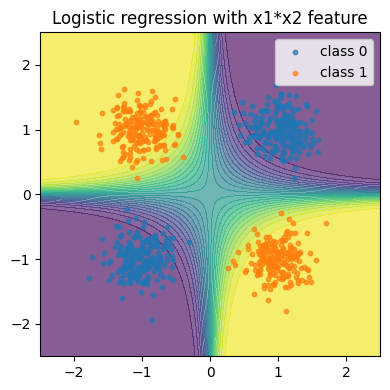

In [ ]:
# Add an interaction feature: x3 = x1 * x2
X3 = (X[:, 0] * X[:, 1]).reshape(-1, 1).astype(np.float32)
X_fe_t = torch.from_numpy(np.concatenate([X.astype(np.float32), X3], axis=1))

logreg_fe = nn.Linear(3, 1)
opt = torch.optim.SGD(logreg_fe.parameters(), lr=0.5)
for _ in range(400):
    opt.zero_grad()
    loss = nn.BCEWithLogitsLoss()(logreg_fe(X_fe_t), y_t)
    loss.backward()
    opt.step()

with torch.no_grad():
    print(f"Logistic regression + x1*x2 feature accuracy: {accuracy_from_logits(logreg_fe(X_fe_t), y_t):.3f}")

fig, ax = plt.subplots(figsize=(4, 4))
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 250), np.linspace(-2.5, 2.5, 250))
grid_xy = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_x3 = (grid_xy[:, 0] * grid_xy[:, 1]).reshape(-1, 1)
grid_fe = torch.from_numpy(np.concatenate([grid_xy, grid_x3], axis=1))
with torch.no_grad():
    probs = torch.sigmoid(logreg_fe(grid_fe)).reshape(xx.shape).cpu().numpy()
ax.contourf(xx, yy, probs, levels=25, alpha=0.65)
scatter_data(ax)
ax.set_title("Logistic regression with x1*x2 feature")
plt.tight_layout()
plt.show()

## Why activations are the key ingredient

A common misunderstanding: "if one linear layer isn't enough, let's stack two."

But **linear → linear is still linear** — the composition collapses into a single linear transformation. Stacking layers only becomes interesting once you insert **non-linear activations** (ReLU, tanh, …) between them.

In [ ]:
# Proof: two stacked linear layers = one linear layer
torch.manual_seed(0)
layer1 = nn.Linear(2, 4)
layer2 = nn.Linear(4, 1)

x = torch.randn(10, 2)
y_stacked = layer2(layer1(x))

# Equivalent single linear layer
W_equiv = layer2.weight @ layer1.weight
b_equiv = layer2.bias + (layer2.weight @ layer1.bias)
y_equiv = x @ W_equiv.T + b_equiv

print(f"Max difference: {(y_stacked - y_equiv).abs().max().item():.6g}")

Max difference: 2.98023e-08


## Non-linearity: a tiny MLP solves XOR

Instead of manually adding `x₁ × x₂`, we use a small network with an activation function. The hidden layer **learns** intermediate "detectors" that behave like engineered features — but learned from data.

MLP accuracy: 1.000


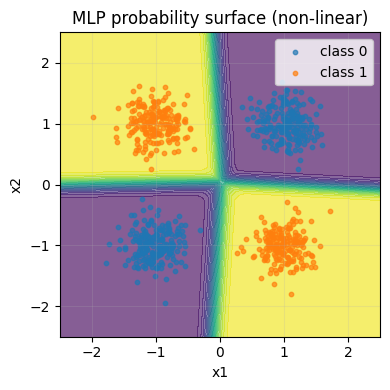

In [ ]:
mlp = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1))
opt = torch.optim.Adam(mlp.parameters(), lr=0.05)
bce = nn.BCEWithLogitsLoss()

for _ in range(600):
    opt.zero_grad()
    loss = bce(mlp(X_t), y_t)
    loss.backward()
    opt.step()

with torch.no_grad():
    print(f"MLP accuracy: {accuracy_from_logits(mlp(X_t), y_t):.3f}")

fig, ax = plt.subplots(figsize=(4, 4))
plot_probability_surface(ax, mlp, "MLP probability surface (non-linear)")
scatter_data(ax)
plt.tight_layout()
plt.show()

## Universal Approximation Theorem

> A feedforward network with a single hidden layer containing **enough** neurons can approximate any continuous function on a compact subset of ℝⁿ.

**Implications:**
- MLPs are theoretically powerful enough for any task.
- "Enough" neurons may be impractically large.
- Deeper networks often work better than wider ones in practice.
- Finding the right weights is the hard part (training).

## Hidden layer size experiment

In [ ]:
hidden_sizes = [2, 4, 8, 16, 32]
results = {}

for h in hidden_sizes:
    mlp = nn.Sequential(nn.Linear(2, h), nn.ReLU(), nn.Linear(h, 1))
    opt = torch.optim.Adam(mlp.parameters(), lr=0.05)
    for _ in range(600):
        opt.zero_grad()
        bce(mlp(X_t), y_t).backward()
        opt.step()
    with torch.no_grad():
        results[h] = accuracy_from_logits(mlp(X_t), y_t)
    print(f"Hidden size {h:2d}: {results[h]:.3f}")

Hidden size  2: 0.999
Hidden size  4: 0.999
Hidden size  8: 1.000
Hidden size 16: 1.000
Hidden size 32: 1.000


Even 2 hidden neurons can represent XOR (matching the 2 "detectors" we need), but more neurons make training more robust — the optimizer has more paths to a solution.

## What to take away

- XOR is a *toy dataset*, but the idea it represents (**feature interactions**) is everywhere.
- Linear regression / logistic regression / perceptron share the same *linear score* core.
- To handle non-linear problems, you need either:
  - **Feature engineering** (manually adding interaction features), or
  - **Non-linear models** (hidden layers + activation functions).
- This is the real reason activations matter: they let models build rich representations instead of being stuck with straight boundaries.
- The **Universal Approximation Theorem** guarantees that a single hidden layer *can* represent any function — but deeper networks are usually more practical.